In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.3 MB/s eta 0:00:00


In [2]:
import cv2
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
model = YOLO('yolov8n.pt')

In [67]:
video_path = '/content/02-01-05-02-02-01-05.mp4'
cap = cv2.VideoCapture(video_path)

In [68]:
ret, frame = cap.read()

In [69]:
results = model(frame)


0: 384x640 1 person, 19.1ms
Speed: 4.5ms preprocess, 19.1ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


In [70]:
boxes = results[0].boxes
print(boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.8984], device='cuda:0')
data: tensor([[3.2703e+02, 2.1807e+01, 9.7326e+02, 7.1400e+02, 8.9838e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (720, 1280)
shape: torch.Size([1, 6])
xywh: tensor([[650.1450, 367.9029, 646.2263, 692.1916]], device='cuda:0')
xywhn: tensor([[0.5079, 0.5110, 0.5049, 0.9614]], device='cuda:0')
xyxy: tensor([[327.0319,  21.8071, 973.2582, 713.9987]], device='cuda:0')
xyxyn: tensor([[0.2555, 0.0303, 0.7604, 0.9917]], device='cuda:0')


In [71]:
for box in boxes:
    coords = box.xyxy[0]
    x1, y1, x2, y2 = map(int, coords)
    print(x1, y1, x2, y2)

327 21 973 713


In [72]:
cropped = frame[y1:y2, x1:x2]

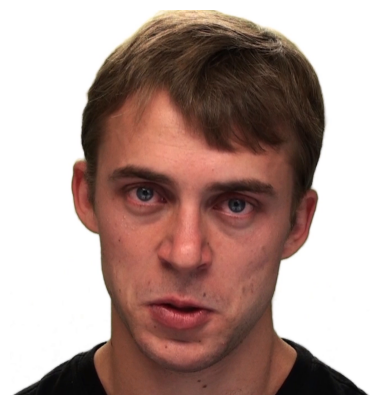

In [73]:
plt.figure(figsize=(5,5))
plt.imshow(
    cv2.cvtColor(
        cropped,
        cv2.COLOR_BGR2RGB
    )
)
plt.axis('off')

plt.show()

In [76]:
cv2.imwrite(
    'cropped_face.jpg',
    cropped
)

True